# Exploratory Data Analysis: Twitter Election Polls

This notebook represents the first step in the data pipeline. It explores the foundational poll dataset before any downstream markers (candidate order, formality, political leaning) have been extracted.

The goal is to understand the raw data collected from Decahose, Vote, and Voting APIs, observing distributions of votes, author partisanship, and audience characteristics.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))
from bias_analysis.dataset import get_base_dataset

from loguru import logger
logger.remove()


## 1. Load Base Dataset
We use `get_base_dataset()` to load raw polling data, integrating author partisanship and audience metrics where available.

In [9]:
df = get_base_dataset()

print(f"Base dataset loaded with {len(df)} polls and {len(df.columns)} features.\n")
print(df.info())
df.head()

Loading polls.jsonl: 14171it [00:00, 21845.68it/s]
Loading poll-vote-2020.jsonl: 1440it [00:00, 35511.51it/s]
Loading poll-voting-2020.jsonl: 725it [00:00, 34152.88it/s]
Loading partisanship_scores_final.jsonl: 75919it [00:00, 279247.54it/s]
Loading partisanship_scores_all_users.jsonl: 33150it [00:00, 370923.85it/s]
Loading partisan-voting-2020.jsonl: 26332it [00:00, 352931.97it/s]
Loading m3inf_output_final.jsonl: 59940it [00:00, 156419.17it/s]
Loading m3inf_output_all_users.jsonl: 28616it [00:00, 161951.29it/s]
Loading m3inf-voting-2020.jsonl: 2337it [00:00, 153167.20it/s]
Loading retweeters.jsonl: 2481it [00:00, 23837.28it/s]
Loading retweet-vote-2020.jsonl: 1504it [00:00, 10792.12it/s]
Loading retweet-voting-2020.jsonl: 725it [00:00, 10986.76it/s]
Loading favoriters.jsonl: 5214it [00:00, 12298.12it/s]
Loading favorite-vote-2020.jsonl: 1440it [00:00, 19678.61it/s]
Loading favoriters-voting-2020.jsonl: 725it [00:00, 17834.91it/s]


Base dataset loaded with 7470 polls and 17 features.

<class 'pandas.DataFrame'>
RangeIndex: 7470 entries, 0 to 7469
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      7470 non-null   str    
 1   author_id                     7470 non-null   str    
 2   created_at                    6698 non-null   str    
 3   tweet_text                    7470 non-null   str    
 4   data_source                   7470 non-null   str    
 5   duration_minutes              7028 non-null   float64
 6   n_options                     7470 non-null   int64  
 7   total_votes                   7470 non-null   int64  
 8   poll_options                  7470 non-null   str    
 9   user_id                       6318 non-null   str    
 10  author_partisanship_raw       6318 non-null   float64
 11  author_partisanship           6318 non-null   float64
 12  user_id_demo       

,tweet_id,author_id,created_at,tweet_text,data_source,duration_minutes,n_options,total_votes,poll_options,user_id,author_partisanship_raw,author_partisanship,user_id_demo,author_org_prob,audience_mean_partisanship,audience_median_partisanship,audience_n_distinct_users
0,1221361006535790592,1100725849358303235,Sun Jan 26 09:15:30 +0000 2020,Who Will 2020 United States PRESIDENTIAL ELECT...,decahose,10080.0,4,2,"[{'position': 1, 'label': 'Donald Trump', 'vot...",1100725849358303235,0.796107,0.796107,1100725849358303235,0.0015,NaN,NaN,0
1,1222264765373919232,778093671254204416,Tue Jan 28 21:06:43 +0000 2020,Who will win the Presidential election? 🇺🇸,decahose,10080.0,4,16,"[{'position': 1, 'label': 'Bernie Sanders', 'v...",778093671254204416,1.495457,1.495457,NaN,NaN,NaN,NaN,0
2,1221625424255602690,1010164874285068288,Mon Jan 27 02:46:12 +0000 2020,Which of the following actually has envisioned...,decahose,1440.0,4,108,"[{'position': 1, 'label': 'Bernie Sanders', 'v...",1010164874285068288,2.335044,2.335044,NaN,NaN,-0.753739,-0.664441,9
3,1215101575322046464,586180854,Thu Jan 09 02:42:45 +0000 2020,If the election were today who would you vote ...,decahose,1440.0,4,452,"[{'position': 1, 'label': 'Biden', 'votes': 53...",586180854,1.145222,1.145222,NaN,NaN,NaN,NaN,0
4,1223290958889881601,779203152637669376,Fri Jan 31 17:04:26 +0000 2020,So just a single poll now based on https://t.c...,decahose,10080.0,4,63,"[{'position': 1, 'label': 'Biden', 'votes': 0}...",779203152637669376,-0.468588,-0.468588,NaN,NaN,NaN,NaN,0


## 2. Poll Sources and Basic Stats
Where did these polls come from, and what do they look like?

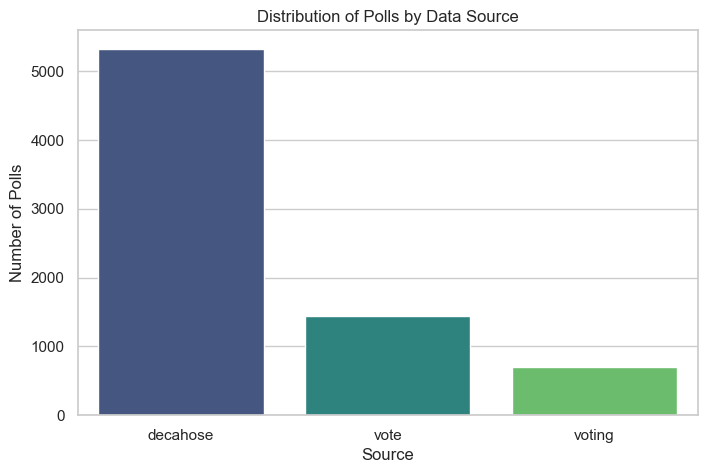

In [3]:
# Distribution of Data Sources
source_counts = df['data_source'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis')
plt.title('Distribution of Polls by Data Source')
plt.ylabel('Number of Polls')
plt.xlabel('Source')
plt.show()

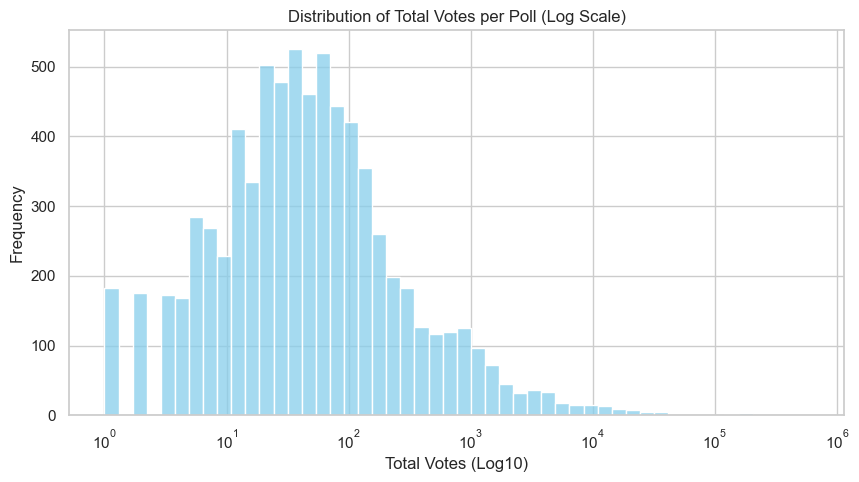

In [4]:
# Distribution of Total Votes (Log Scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['total_votes'].dropna(), bins=50, log_scale=True, color="skyblue")
plt.title('Distribution of Total Votes per Poll (Log Scale)')
plt.xlabel('Total Votes (Log10)')
plt.ylabel('Frequency')
plt.show()

## 3. Author Characteristics
We look at the inferred partisanship score of the poll authors, normalized to represent standard deviations from the mean.

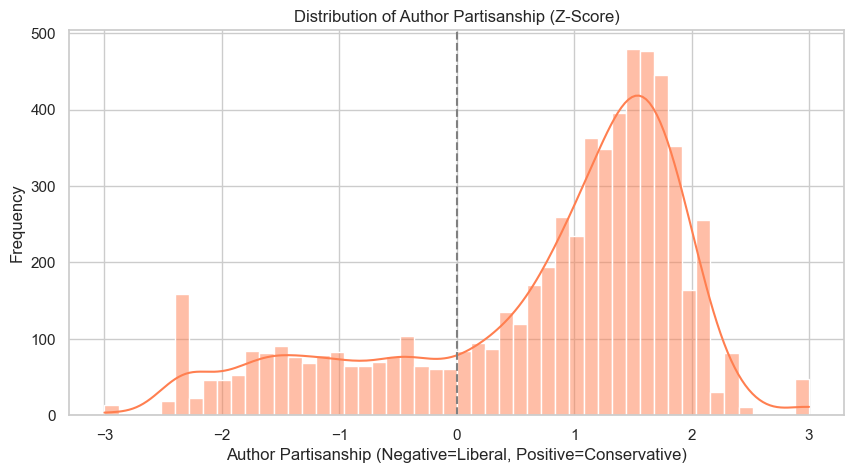

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['author_partisanship'].dropna(), bins=50, color="coral", kde=True)
plt.title('Distribution of Author Partisanship (Z-Score)')
plt.xlabel('Author Partisanship (Negative=Liberal, Positive=Conservative)')
plt.ylabel('Frequency')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

## 4. Audience Engagement Characteristics
Audience characteristics are based on users who retweeted or favorited the poll. Here we look at the mean partisanship of the audience.

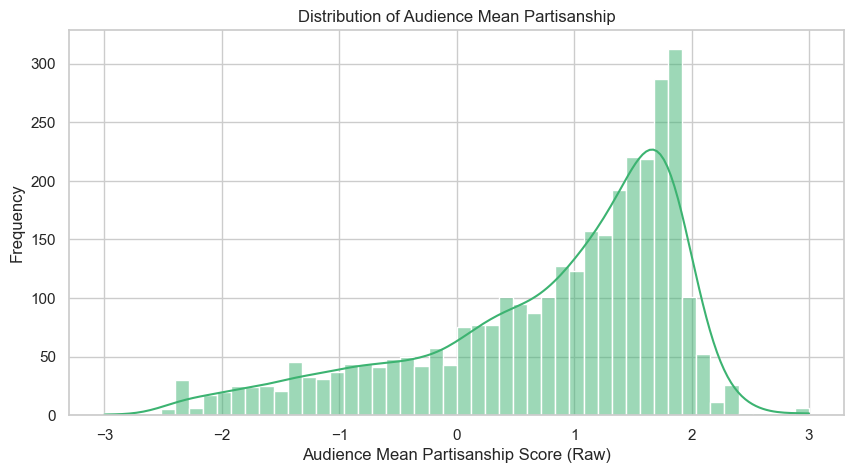

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['audience_mean_partisanship'].dropna(), bins=50, color="mediumseagreen", kde=True)
plt.title('Distribution of Audience Mean Partisanship')
plt.xlabel('Audience Mean Partisanship Score (Raw)')
plt.ylabel('Frequency')
plt.show()

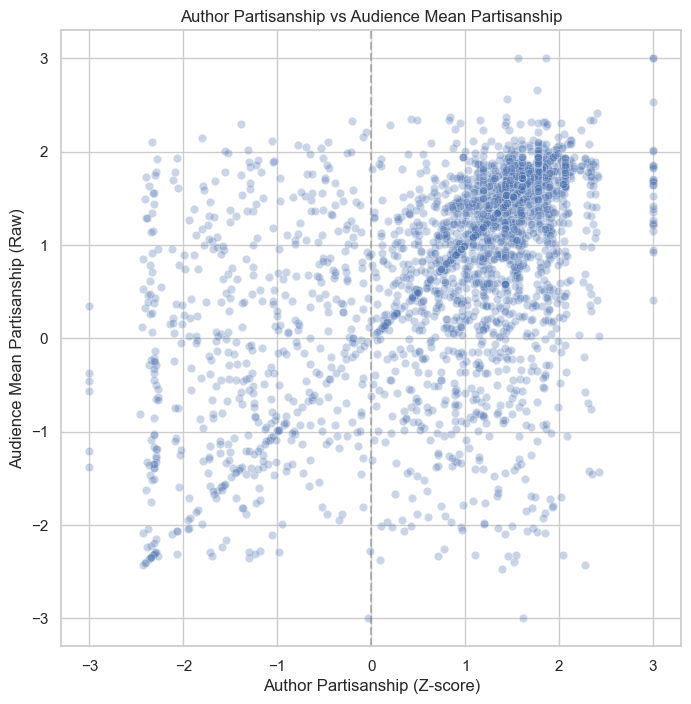

In [7]:
# Relationship between Author and Audience Partisanship
plot_df = df.dropna(subset=['author_partisanship', 'audience_mean_partisanship'])

plt.figure(figsize=(8, 8))
sns.scatterplot(data=plot_df, x='author_partisanship', y='audience_mean_partisanship', alpha=0.3)
plt.title('Author Partisanship vs Audience Mean Partisanship')
plt.xlabel('Author Partisanship (Z-score)')
plt.ylabel('Audience Mean Partisanship (Raw)')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()